# Intelligent Agents: Reflex-Based Agents for GridHunt

Student Name: Trương Văn Thiện

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: Thiện

## Learning Outcomes

* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.

## Instructions

Total Points: Undergrads 10

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook.
### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

## Introduction

![GridHunt Image](gridhunt.png)

Gridhunt is a small educational game that helps you practice implementing simple agent functions. It is a modified Python reimplementation of Gridhunt2. 

The objective of gridhunt is to implement an intelligent agent, the hunter, who can catch a monster faster than all other hunters. Gridhunt uses a $n \times n$ arena consisting of a grid of tiles. Gridhunt is a turn-based game, and the hunter and the monster move on this grid. A hunter catches the monster if she/he moves on the same square the monster currently occupies. If the monster survives the maximum number of steps for the game, then the monster wins.

## PEAS Description of Gridhunt

__Performance Measure:__ The performance is measured as the number of steps the hunter uses to catch the monster. Catching the monster means to be on the same square.

__Environment:__ An arena with $n \times n$ squares. At the beginning the monster and the hunter are randomly placed in the arena environment. The hunter and the monster
    can move around, but cannot leave the arena.

__Actuators:__ The agent can move to an adjacent square using actions "north", "east", "west", and "south", or teleport which will move the agent 
    to a random square in the arena.

__Sensors:__ The agent can always see its location in the arena but only gets the monster location when it stops and listens.

## The Arena Environment

The environment manages the location of the agents (hunter and monster). It initially places them in a random location and then provides them in every step with percepts (the location of the hunter and the monster) and asks them for their action. 

__A Note on positions:__
The arena is implemented as an array with row and column indices representing the position.
Positions are stored in a numpy array where `pos[0]` is the row index and `pos[1]` is the column index in the arena. North means up in this array, that is the row index gets smaller when going north. Remember indices in Python start with 0 and go to `n-1`.

In [1]:
import numpy as np
from IPython.display import clear_output
from time import sleep

def arena_environment(hunter_agent_function, 
                      monster_agent_function, 
                      n = 30, max_steps = 100, 
                      visualize = False, animation = False):
    """
    Simulate an arena where a hunter agent tries to catch a monster agent.

    Parameters:
    hunter_agent_function (function): A function that takes the current positions of the hunter and monster
                                      and returns the next move for the hunter ('north', 'east', 'west', 'south', 'teleport').
    monster_agent_function (function): A function that takes the current positions of the hunter and monster
                                       and returns the next move for the monster (or 'stay' to remain in place).
    n (int): The size of the arena (n x n grid).
    max_steps (int): The maximum number of steps to simulate.
    visualize (bool): Whether to visualize the arena.
    animation (bool): Whether to animate the visualization with a delay.

    Returns:
    int: The number of steps taken for the hunter to catch the monster or np.nan (not a number) if not caught.
    """
    
    # Initialize positions
    monster_pos = np.random.randint(0, n-1, size=2)
    hunter_pos = np.random.randint(0, n-1, size=2)
    
    def move(action, position):
        """calculate new position for the agent."""
        if action == 'north':
            position[0] -= 1
        elif action == 'south':
            position[0] += 1
        elif action == 'west':
            position[1] -= 1
        elif action == 'east':
            position[1] += 1
        else:
            raise ValueError("Invalid action.")
        
        # Ensure position stays within bounds
        position = np.clip(position, 0, n-1)
        return position

    def print_arena():

        if animation:
            sleep(1)
            clear_output(wait=True)
        print(f"Step {step+1}: Hunter is at '{hunter_pos}'; Monster is at '{monster_pos}'")
        arena = np.full((n, n), '.', dtype=str)
        arena[monster_pos[0], monster_pos[1]] = 'M'
        arena[hunter_pos[0], hunter_pos[1]] = 'H'
        if np.array_equal(hunter_pos, monster_pos):
            arena[monster_pos[0], monster_pos[1]] = '*'
        print("\n".join("".join(row) for row in arena))

    # run the environment
    hunter_action = None  # Initialize hunter_action to None for the first step
    for step in range(max_steps):
        if visualize:
            print_arena()
        
        # Check if hunter has caught the monster
        if np.array_equal(hunter_pos, monster_pos):
            if visualize:
                print(f"Hunter caught the monster in {step} steps!")
            return step
        
        # Get next move from monster agent function
        monster_action = monster_agent_function(hunter_pos, monster_pos)
        
        if monster_action != 'stay':
            monster_pos = move(monster_action, monster_pos)

        # Get next move from hunter agent function. The monster's position is only provided 
        # if the hunter chose 'listen' as the previous action.
        if hunter_action == 'listen':
            monster_pos_instrument = monster_pos
        else: 
            monster_pos_instrument = None
        
        hunter_action = hunter_agent_function(hunter_pos, monster_pos_instrument)
        
        if hunter_action == 'listen':
            pass
        elif hunter_action == 'teleport':
            hunter_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_pos = move(hunter_action, hunter_pos)
    
        # print the agents' actions
        if visualize:
            print(f"Hunter chose action '{hunter_action}'")
            print(f"Monster chose action '{monster_action}'")
            print("\n")

    # the hunter failed to catch the monster within max_steps
    if visualize:
        print(f"Hunter failed to catch the monster in {max_steps} steps.")
    
    return np.nan

I implement the monster here as a simple agent that moves around randomly, but mostly stays in its place. You can use AI to get a detailed explanation of how the following code works.

In [2]:
monster_actions = ["north", "east", "west", "south", "stay"]

def monster_agent_function_simple(hunter_pos, monster_pos):
    return np.random.choice(monster_actions, p=[0.125, 0.125, 0.125, 0.125, 0.5])

# The Hunter Agent

Your job is to implement a simple-reflex hunter agent that can catch the monster. Remember, your agent is implemented as an agent function that get percepts and needs to return a valid action. The actions are: 

In [3]:
actions = ["north", "east", "west", "south", "teleport", "listen"]

## A Simple Example Implementation

Here is a very simple hunter that just runs around randomly and hopes that it bumps into the monster. 

In [4]:
def simple_randomized_hunter_agent_function(hunter_location, monster_location):
    return np.random.choice(actions)

Ask the agent for an action.

In [5]:
simple_randomized_hunter_agent_function([0,0], None)

np.str_('east')

## Experimenting With the Agent

We can place the monster and the hunter into the environment and run a simulation by calling the environment function.

In [6]:
arena_environment(simple_randomized_hunter_agent_function, 
                  monster_agent_function_simple, 
                  n=5, max_steps=10, visualize=True, animation=False)

Step 1: Hunter is at '[0 2]'; Monster is at '[0 2]'
..*..
.....
.....
.....
.....
Hunter caught the monster in 0 steps!


0

**Note for VS Code:** View as scrollable element to see the complete output.

Well, this was one run, maybe it was just good or bad luck this time!

Let's run an experiment with 100 runs in a $10 \times 10$ arena.  

In [7]:
steps = [arena_environment(simple_randomized_hunter_agent_function, monster_agent_function_simple, n=10, max_steps=100, visualize=False) for _ in range(100)] 
print(steps)

[56, 34, nan, nan, nan, 43, 95, nan, nan, nan, 50, nan, nan, 20, nan, 0, 18, nan, nan, 5, 57, nan, nan, nan, nan, 4, 42, nan, 5, nan, 81, 83, 35, nan, 35, nan, 44, 86, nan, 3, 41, nan, 23, 56, nan, 28, nan, 20, 5, 90, nan, 2, nan, nan, nan, nan, 13, nan, 53, 23, 0, 51, nan, nan, nan, nan, nan, nan, nan, nan, nan, 48, 15, nan, 65, nan, nan, nan, 14, nan, nan, 80, nan, 63, 34, nan, 71, nan, 51, nan, 86, 27, nan, 78, 56, 87, 74, nan, nan, 54]


We just got a list with the number of steps to catch the monster for 100 simulation runs.
Let's analysis the results. `nan` means that the hunter was not able to catch the monster. How many times did that happen? To answer how well the hunter did when it caught the monster, we just average the numbers that are not `nan`. 

In [8]:
print (f"Hunter failed {np.sum(np.isnan(steps))} times.")
print (f"Average steps to catch the monster over {np.sum(~np.isnan(steps))} successful runs: {round(np.nanmean(steps), 2)}")

Hunter failed 51 times.
Average steps to catch the monster over 49 successful runs: 42.94


This in not a very good agent. You need to implement a better agent function.

# Your Agent Implementation [4 points]

Write a new hunter agent function that chases the monster. Copy the simple randomized hunter function from above and make it into a model-based reflex agent. It should use listen to get the monster's location and then move towards the monster. To do that it needs to remember the monster's location. This memory makes it model-based. Here is HOWTO: How to Store State Information in the Agent.

In [9]:
def make_hunter_agent():
    """Tạo một hunter agent function mới với state sạch."""
    known_monster_pos = None  # state riêng, reset mỗi lần gọi make_hunter_agent()

    def hunter_agent_function(hunter_location, monster_location):
        nonlocal known_monster_pos

        # Cập nhật vị trí monster nếu vừa listen
        if monster_location is not None:
            known_monster_pos = list(monster_location)

        # Chưa biết vị trí → listen
        if known_monster_pos is None:
            return 'listen'

        h_row, h_col = hunter_location[0], hunter_location[1]
        m_row, m_col = known_monster_pos[0], known_monster_pos[1]

        row_diff = m_row - h_row
        col_diff = m_col - h_col

        # Đã ở cùng ô → reset và listen lại
        if row_diff == 0 and col_diff == 0:
            known_monster_pos = None
            return 'listen'

        # Di chuyển về phía monster
        if abs(row_diff) >= abs(col_diff):
            return 'south' if row_diff > 0 else 'north'
        else:
            return 'east' if col_diff > 0 else 'west'

    return hunter_agent_function

## Phân tích chiến lược của Hunter Agent

### Loại tác tử
Hunter được cài đặt là một **model-based reflex agent** (tác tử phản xạ dựa trên mô hình). 
Lý do: nó không chỉ phản ứng với percept hiện tại mà còn **lưu trữ trạng thái bên trong** 
(vị trí monster đã nghe được) để ra quyết định ở các bước tiếp theo.

### Trạng thái bên trong (internal state)
Agent sử dụng một biến `known_monster_pos` để lưu vị trí monster gần nhất mà nó đã nghe được:

- `known_monster_pos = None` → agent chưa có thông tin về monster.
- `known_monster_pos = [row, col]` → agent đã biết vị trí monster (từ lần `listen` gần nhất).

State này được tạo **bên trong hàm `make_hunter_agent()`** bằng closure (`nonlocal`), 
nên mỗi lần gọi `make_hunter_agent()` sẽ sinh ra một agent hoàn toàn mới, 
tránh rò rỉ trạng thái giữa các lần mô phỏng.

### Chiến lược chọn hành động
Ở mỗi bước, agent thực hiện theo thứ tự ưu tiên:

1. **Nếu vừa nhận được vị trí monster** (`monster_location is not None`) → cập nhật `known_monster_pos`.
2. **Nếu chưa biết vị trí monster** → trả về `'listen'` để lấy thông tin.
3. **Nếu đã ở đúng ô của monster** → reset state và `listen` lại (chuẩn bị cho lần săn tiếp theo).
4. **Ngược lại** → di chuyển greedy theo khoảng cách Manhattan:
   - So sánh `|row_diff|` và `|col_diff|`.
   - Nếu `|row_diff| >= |col_diff|` → đi `north`/`south` để giảm chênh lệch hàng.
   - Ngược lại → đi `east`/`west` để giảm chênh lệch cột.

### Vì sao chiến lược này hiệu quả?
- Monster đứng yên với xác suất 0.5 → vị trí nghe được thường còn chính xác.
- Mỗi bước di chuyển đều giảm khoảng cách Manhattan đi ít nhất 1 đơn vị.
- Không dùng `teleport` → không làm mất tiến độ.
- Khi monster đã di chuyển khỏi vị trí cũ, agent tự động `listen` lại để cập nhật.

# Your Experiments [2 points]

Copy the simulation code from above and run experiments with your agent. 
Experiment with larger arenas of at least size $30 \times 30$.

In [ ]:
# n = 30
steps_30 = [
    arena_environment(make_hunter_agent(),   # <-- tạo agent mới mỗi lần
                      monster_agent_function_simple,
                      n=30, max_steps=500, visualize=False)
    for _ in range(100)
]
print(f"[n=30] Failed: {np.sum(np.isnan(steps_30))} | Avg steps: {round(np.nanmean(steps_30), 2)}")

# n = 50
steps_50 = [
    arena_environment(make_hunter_agent(),   # <-- tạo agent mới mỗi lần
                      monster_agent_function_simple,
                      n=50, max_steps=500, visualize=False)
    for _ in range(100)
]
print(f"[n=50] Failed: {np.sum(np.isnan(steps_50))} | Avg steps: {round(np.nanmean(steps_50), 2)}")
steps_100 = [
    arena_environment(make_hunter_agent(),   # <-- tạo agent mới mỗi lần
                      monster_agent_function_simple,
                      n=100, max_steps=500, visualize=False)
    for _ in range(100)
]

print(f"[n=100] Failed: {np.sum(np.isnan(steps_100))} | Avg steps: {round(np.nanmean(steps_100), 2)}")

[n=30] Failed: 0 | Avg steps: 26.09
[n=50] Failed: 0 | Avg steps: 41.53
[n=100] Failed: 0 | Avg steps: 79.03


## Bảng tổng hợp kết quả thí nghiệm

| Kích thước arena | Số lần chạy | Số lần thất bại | Số bước trung bình |
|:----------------:|:-----------:|:---------------:|:------------------:|
| 30 × 30          | 100         | 0               | 26.09              |
| 50 × 50          | 100         | 0               | 41.53              |
| 100 × 100        | 100         | 0               | 79.03              |

### Nhận xét kết quả

#### Vì sao số bước trung bình tăng khi n tăng?
Khi arena lớn hơn, khoảng cách ban đầu trung bình giữa hunter và monster cũng lớn hơn. Với hai điểm ngẫu nhiên trên lưới n × n, khoảng cách Manhattan trung bình xấp xỉ:
                    E[distance] ≈ 2n/3

Ví dụ:

n = 30: khoảng cách trung bình lý thuyết ≈ 20 bước. Thực tế là 26.09 bước.

n = 50: khoảng cách trung bình lý thuyết ≈ 33.33 bước. Thực tế là 41.53 bước.

n = 100: khoảng cách trung bình lý thuyết ≈ 66.67 bước. Thực tế là 79.03 bước.

Phần chênh lệch thêm là do:

Hunter mất 1 bước để listen lần đầu.

Monster thỉnh thoảng di chuyển, nên khi hunter đến vị trí cũ thì monster đã đi chỗ khác.

Hunter phải listen lại nhiều lần, mỗi lần mất thêm bước.

Arena càng lớn, monster càng có nhiều không gian để di chuyển, nên số lần phải listen lại cũng tăng.

Vì max_steps = 500 là quá đủ lớn so với số bước trung bình, nên cả 3 trường hợp đều có 0 lần thất bại.

## Vẽ biểu đồ so sánh

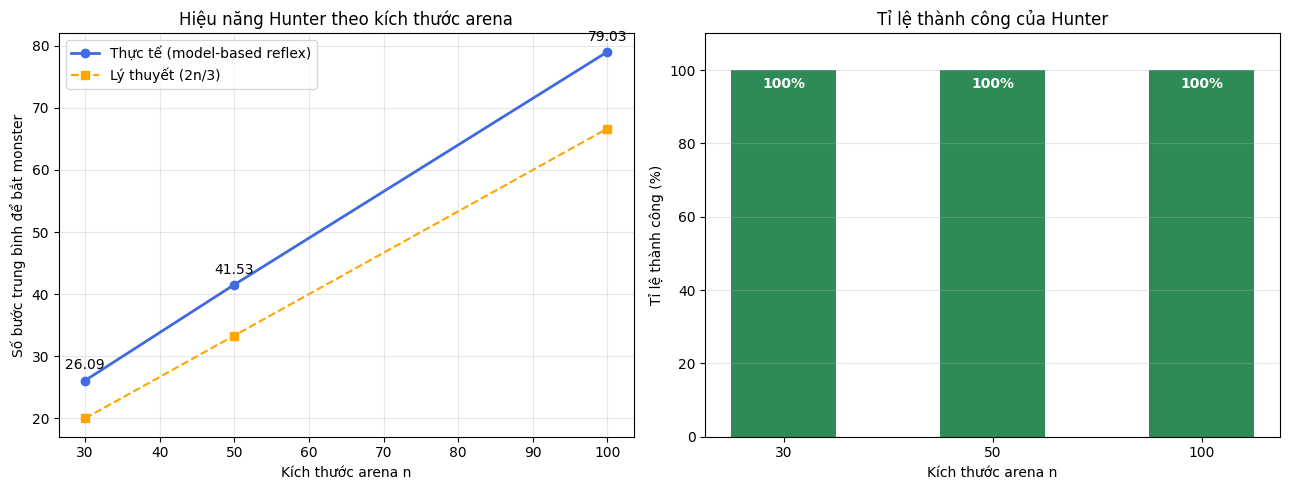

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu từ thí nghiệm
sizes = [30, 50, 100]
avg_steps = [26.09, 41.53, 79.03]
theoretical = [2 * n / 3 for n in sizes]   # khoảng cách Manhattan trung bình lý thuyết
failures = [0, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Biểu đồ 1: Số bước trung bình theo kích thước arena ---
axes[0].plot(sizes, avg_steps, marker='o', linewidth=2,
             color='royalblue', label='Thực tế (model-based reflex)')
axes[0].plot(sizes, theoretical, marker='s', linestyle='--',
             color='orange', label='Lý thuyết (2n/3)')
for x, y in zip(sizes, avg_steps):
    axes[0].annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=10)
axes[0].set_xlabel("Kích thước arena n")
axes[0].set_ylabel("Số bước trung bình để bắt monster")
axes[0].set_title("Hiệu năng Hunter theo kích thước arena")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# --- Biểu đồ 2: Tỉ lệ thành công / thất bại ---
success = [100 - f for f in failures]
bars = axes[1].bar([str(n) for n in sizes], success,
                   color='seagreen', width=0.5)
for bar, s in zip(bars, success):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 5,
                 f"{s}%", ha='center', color='white', fontweight='bold')
axes[1].set_xlabel("Kích thước arena n")
axes[1].set_ylabel("Tỉ lệ thành công (%)")
axes[1].set_ylim(0, 110)
axes[1].set_title("Tỉ lệ thành công của Hunter")
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Your Conclusion [4 points] 

Discuss the following:

* What is your hunter's final strategy to choose actions. Why does it work well?
* Do you use teleportation. Why and in what situation? Why not?
* How does the arena size affects your hunter agent's performance?

> Your discussion goes here
#### - Chiến lược của hunter
Hunter của em là một model-based reflex agent. Ban đầu khi chưa biết vị trí monster, hunter chọn listen. Khi nhận được vị trí monster, nó lưu vị trí đó vào bộ nhớ known_monster_pos. Sau đó, hunter di chuyển greedily theo khoảng cách Manhattan: nếu chênh lệch hàng lớn hơn hoặc bằng chênh lệch cột thì đi theo hướng bắc/nam để giảm chênh lệch hàng; ngược lại thì đi đông/tây để giảm chênh lệch cột. Khi hunter đến vị trí đã nhớ, nó xóa bộ nhớ và listen lại.

Chiến lược này hoạt động tốt vì monster chủ yếu đứng yên với xác suất 0.5, nên vị trí nghe được còn khá chính xác. Hunter chỉ cần di chuyển về phía mục tiêu và thỉnh thoảng cập nhật lại vị trí monster.

#### - Có dùng teleport không? Vì sao?
Không. Trong môi trường này, teleport đưa hunter đến một ô ngẫu nhiên, có thể làm hunter xa monster hơn, mất tiến độ và tốn một bước. Trong khi đó, listen cho biết chính xác vị trí monster, nên hữu ích hơn nhiều. Teleport chỉ có thể cân nhắc nếu không được phép listen, hoặc nếu hunter bị mắc kẹt và không có thông tin về monster.

#### - Ảnh hưởng của kích thước arena
Khi kích thước arena tăng, khoảng cách ban đầu trung bình giữa hunter và monster tăng theo xấp xỉ 2n/3, đồng thời monster cũng có nhiều không gian hơn để di chuyển. Vì vậy, số bước trung bình để bắt monster tăng gần như tuyến tính theo n. Với max_steps đủ lớn như 500, hunter vẫn bắt được monster trong cả ba trường hợp n = 30, 50, 100. Nếu max_steps quá nhỏ so với n, tỉ lệ thất bại sẽ tăng.

#### - Monster có thể cải thiện như thế nào?
Monster hiện tại di chuyển ngẫu nhiên và thường đứng yên. Để tránh hunter tốt hơn, monster có thể dùng thông tin hunter_pos mà môi trường cung cấp mỗi bước.

Ý tưởng:

- Nếu hunter ở gần, monster nên chọn bước di chuyển làm tăng khoảng cách Manhattan với hunter.
- Nếu bị dồn vào góc hoặc sát tường, chọn hướng vuông góc để thoát.
- Nếu hunter ở xa, monster có thể đứng yên để tránh vô tình đi vào hunter.
- Có thể nâng cao hơn bằng cách nhớ hướng đi của hunter, dự đoán bước tiếp theo, hoặc dùng BFS/minimax để tối đa thời gian sống.

The monster is also an agent. Describe how the monster's agent function could be changed so it gets better at avoiding the hunter.

> Your discussion goes here

# More Work (Optional)

Here are some ideas:

* Implement a better monster agent function and perform experiments
* Change the environment so multiple hunters can hunt the monster.
* Give the hunter a new action that shoots an arrow in a specific direction. 
  The arrow can go a maximum of 5 squares. If the hunter hits the monster, then it wins.